In [10]:
from pathlib import Path
import warnings

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

ROOT = Path("..").resolve()
OUTPUT_TRAINING_DIR = ROOT / "output" / "training_set"

if not OUTPUT_TRAINING_DIR.exists():
    raise FileNotFoundError(f"Folder tidak ditemukan: {OUTPUT_TRAINING_DIR}")

class_dirs = sorted([p for p in OUTPUT_TRAINING_DIR.iterdir() if p.is_dir()])
class_names = [p.name for p in class_dirs]

print(f"Root: {ROOT}")
print(f"Output training set: {OUTPUT_TRAINING_DIR}")
print(f"Classes ({len(class_names)}): {class_names}")

Root: D:\Thoriq\Work\MadeByHumans\Research Face Shape
Output training set: D:\Thoriq\Work\MadeByHumans\Research Face Shape\output\training_set
Classes (5): ['Heart', 'Oblong', 'Oval', 'Round', 'Square']


## 1) Load Metrics Semua Kelas


Menggabungkan seluruh file `metrics.csv` menjadi satu DataFrame untuk analisis lintas kelas.

In [11]:
records = []
missing_metrics = []

for cls_dir in class_dirs:
    metrics_path = cls_dir / "metrics.csv"
    if not metrics_path.exists():
        missing_metrics.append(str(metrics_path))
        continue

    df = pd.read_csv(metrics_path)
    df["class_from_folder"] = cls_dir.name
    df["metrics_path"] = str(metrics_path)

    if "class_name" not in df.columns:
        df["class_name"] = cls_dir.name

    if "image_file" not in df.columns and "relative_path" in df.columns:
        df["image_file"] = df["relative_path"].astype(str).map(lambda x: Path(x).name)
    elif "image_file" not in df.columns:
        df["image_file"] = ""

    records.append(df)

if not records:
    raise ValueError("Tidak ada metrics.csv yang berhasil dibaca dari output/training_set")

metrics_df = pd.concat(records, ignore_index=True)

folder_name_map = {c.name.lower(): c.name for c in class_dirs}
metrics_df["class_name"] = (
    metrics_df["class_name"]
    .astype(str)
    .str.strip()
    .map(lambda x: folder_name_map.get(x.lower(), x))
)

if "relative_path" not in metrics_df.columns:
    metrics_df["relative_path"] = metrics_df.apply(
        lambda r: f"{r['class_name']}/{r['image_file']}" if str(r["image_file"]).strip() else "",
        axis=1,
    )
else:
    missing_rel = metrics_df["relative_path"].isna() | (metrics_df["relative_path"].astype(str).str.strip() == "")
    metrics_df.loc[missing_rel, "relative_path"] = metrics_df.loc[missing_rel].apply(
        lambda r: f"{r['class_name']}/{r['image_file']}" if str(r["image_file"]).strip() else "",
        axis=1,
    )

def build_image_path(row, subfolder: str) -> Path:
    cls = str(row["class_name"]).strip()
    img_file = str(row.get("image_file", "")).strip()
    if not img_file:
        rel = str(row.get("relative_path", "")).strip()
        img_file = Path(rel).name if rel else ""
    return OUTPUT_TRAINING_DIR / cls / subfolder / img_file

metrics_df["face_masked_path"] = metrics_df.apply(lambda r: build_image_path(r, "face_masked"), axis=1)
metrics_df["face_skin_path"] = metrics_df.apply(lambda r: build_image_path(r, "face_skin"), axis=1)
metrics_df["face_masked_exists"] = metrics_df["face_masked_path"].map(lambda p: p.exists())
metrics_df["face_skin_exists"] = metrics_df["face_skin_path"].map(lambda p: p.exists())

for col in ["face_masked_path", "face_skin_path"]:
    metrics_df[col] = metrics_df[col].astype(str)

print("Rows total:", len(metrics_df))
print("Missing metrics.csv:", len(missing_metrics))
if missing_metrics:
    print("Contoh file metrics hilang:", missing_metrics[:3])

display(metrics_df.head(3))

Rows total: 3863
Missing metrics.csv: 0


,class_name,image_file,relative_path,face_height,face_width,forehead_height,jaw_width,chin_width,chin_angle_degree,forehead_width,skeleton_angle_left,skeleton_angle_right,jidat_angle_downward,class_from_folder,metrics_path,face_masked_path,face_skin_path,face_masked_exists,face_skin_exists
0,Heart,heart (35).jpg,Heart/heart (35).jpg,0.817466,0.634720,0.305936,0.525610,0.311039,106.405281,0.552511,-5.117314,8.686354,199.631714,Heart,D:\Thoriq\Work\MadeByHumans\Research Face Shap...,D:\Thoriq\Work\MadeByHumans\Research Face Shap...,D:\Thoriq\Work\MadeByHumans\Research Face Shap...,True,True
1,Heart,heart (680).jpg,Heart/heart (680).jpg,0.849408,0.638011,0.328042,0.526694,0.304417,105.287170,0.537037,-10.060691,8.673173,153.951828,Heart,D:\Thoriq\Work\MadeByHumans\Research Face Shap...,D:\Thoriq\Work\MadeByHumans\Research Face Shap...,D:\Thoriq\Work\MadeByHumans\Research Face Shap...,True,True
2,Heart,heart (99).jpg,Heart/heart (99).jpg,0.912541,0.632895,0.408163,0.521866,0.291603,107.177673,0.568513,-9.027613,2.675426,139.843445,Heart,D:\Thoriq\Work\MadeByHumans\Research Face Shap...,D:\Thoriq\Work\MadeByHumans\Research Face Shap...,D:\Thoriq\Work\MadeByHumans\Research Face Shap...,True,True


## 2) Data Quality & Konsistensi Aset Gambar


Cek kelengkapan data per kelas, validitas numeric metrics, serta konsistensi path gambar hasil flow (`face_masked` dan `face_skin`).

In [12]:
metadata_cols = {
    "class_name", "class_from_folder", "image_file", "relative_path",
    "metrics_path", "face_masked_path", "face_skin_path",
    "face_masked_exists", "face_skin_exists",
}

candidate_cols = [c for c in metrics_df.columns if c not in metadata_cols]
for c in candidate_cols:
    metrics_df[c] = pd.to_numeric(metrics_df[c], errors="coerce")

numeric_cols = metrics_df.select_dtypes(include=[np.number]).columns.tolist()

quality_per_class = (
    metrics_df.groupby("class_name", as_index=False)
    .agg(
        rows_total=("class_name", "size"),
        unique_images=("image_file", "nunique"),
        masked_found=("face_masked_exists", "sum"),
        skin_found=("face_skin_exists", "sum"),
    )
    .sort_values("class_name")
)
quality_per_class["masked_found_pct"] = (quality_per_class["masked_found"] / quality_per_class["rows_total"] * 100).round(2)
quality_per_class["skin_found_pct"] = (quality_per_class["skin_found"] / quality_per_class["rows_total"] * 100).round(2)

print("Kolom numeric:", numeric_cols)
display(quality_per_class)

if numeric_cols:
    missing_ratio = (metrics_df[numeric_cols].isna().mean() * 100).sort_values(ascending=False).round(2)
    print("\nMissing ratio (%) per fitur:")
    display(missing_ratio.to_frame("missing_pct"))
else:
    print("Tidak ada kolom numeric yang terdeteksi.")

Kolom numeric: ['face_height', 'face_width', 'forehead_height', 'jaw_width', 'chin_width', 'chin_angle_degree', 'forehead_width', 'skeleton_angle_left', 'skeleton_angle_right', 'jidat_angle_downward']


,class_name,rows_total,unique_images,masked_found,skin_found,masked_found_pct,skin_found_pct
0,Heart,758,758,758,758,100.0,100.0
1,Oblong,779,779,779,779,100.0,100.0
2,Oval,778,778,778,778,100.0,100.0
3,Round,761,761,761,761,100.0,100.0
4,Square,787,787,787,787,100.0,100.0



Missing ratio (%) per fitur:


,missing_pct
face_height,0.0
face_width,0.0
forehead_height,0.0
jaw_width,0.0
chin_width,0.0
chin_angle_degree,0.0
forehead_width,0.0
skeleton_angle_left,0.0
skeleton_angle_right,0.0
jidat_angle_downward,0.0


## 3) Ringkasan Statistik Per Kelas


Pemisahan fitur menjadi **ratio/normalized** dan **angle/degree**, lalu dihitung mean, median, std, min, max per kelas untuk bahan rule-based.

In [13]:
def split_features(numeric_columns):
    angle_cols = [c for c in numeric_columns if ("angle" in c.lower()) or ("degree" in c.lower())]
    ratio_cols = [
        c for c in numeric_columns
        if c not in angle_cols and any(k in c.lower() for k in ["width", "height", "normalized", "ratio"])
    ]
    other_cols = [c for c in numeric_columns if c not in angle_cols and c not in ratio_cols]
    return ratio_cols, angle_cols, other_cols

ratio_cols, angle_cols, other_numeric_cols = split_features(numeric_cols)

print("Ratio/normalized features:", ratio_cols)
print("Angle/degree features:", angle_cols)
print("Other numeric features:", other_numeric_cols)

def build_summary(df, cols, stats=("mean", "median", "std", "min", "max")):
    if not cols:
        return pd.DataFrame()
    out = df.groupby("class_name")[cols].agg(list(stats))
    out.columns = [f"{col}__{stat}" for col, stat in out.columns]
    return out.reset_index()

ratio_summary = build_summary(metrics_df, ratio_cols)
angle_summary = build_summary(metrics_df, angle_cols)

if not ratio_summary.empty:
    print("\nSummary ratio/normalized per kelas")
    display(ratio_summary.round(4))

if not angle_summary.empty:
    print("\nSummary angle/degree per kelas")
    display(angle_summary.round(4))

Ratio/normalized features: ['face_height', 'face_width', 'forehead_height', 'jaw_width', 'chin_width', 'forehead_width']
Angle/degree features: ['chin_angle_degree', 'skeleton_angle_left', 'skeleton_angle_right', 'jidat_angle_downward']
Other numeric features: []

Summary ratio/normalized per kelas


,class_name,face_height__mean,face_height__median,face_height__std,face_height__min,face_height__max,face_width__mean,face_width__median,face_width__std,face_width__min,...,chin_width__mean,chin_width__median,chin_width__std,chin_width__min,chin_width__max,forehead_width__mean,forehead_width__median,forehead_width__std,forehead_width__min,forehead_width__max
0,Heart,0.8573,0.8566,0.0494,0.6236,0.9968,0.6373,0.6353,0.0286,0.5601,...,0.2901,0.2887,0.0170,0.2355,0.3579,0.5168,0.5458,0.1115,0.0048,0.7490
1,Oblong,0.8872,0.8885,0.0412,0.6863,0.9748,0.6059,0.6037,0.0289,0.5338,...,0.2927,0.2907,0.0187,0.2411,0.3646,0.4897,0.5024,0.0933,0.0266,0.6711
2,Oval,0.8808,0.8859,0.0472,0.6228,0.9791,0.6417,0.6389,0.0307,0.5392,...,0.3020,0.3006,0.0181,0.2441,0.3670,0.4972,0.5246,0.1239,0.0364,0.7307
3,Round,0.8553,0.8654,0.0613,0.5307,0.9725,0.6662,0.6638,0.0316,0.5882,...,0.3158,0.3141,0.0178,0.2527,0.3843,0.4578,0.4925,0.1497,0.0078,0.6859
4,Square,0.8744,0.8776,0.0508,0.6045,1.0134,0.6569,0.6539,0.0348,0.5594,...,0.3276,0.3265,0.0216,0.2743,0.4211,0.5164,0.5412,0.1140,0.0105,0.7902



Summary angle/degree per kelas


,class_name,chin_angle_degree__mean,chin_angle_degree__median,chin_angle_degree__std,chin_angle_degree__min,chin_angle_degree__max,skeleton_angle_left__mean,skeleton_angle_left__median,skeleton_angle_left__std,skeleton_angle_left__min,...,skeleton_angle_right__mean,skeleton_angle_right__median,skeleton_angle_right__std,skeleton_angle_right__min,skeleton_angle_right__max,jidat_angle_downward__mean,jidat_angle_downward__median,jidat_angle_downward__std,jidat_angle_downward__min,jidat_angle_downward__max
0,Heart,105.3413,105.2162,4.5434,92.4399,121.4478,-8.2309,-9.4623,5.9035,-28.7612,...,8.6537,9.5650,5.2722,-14.9314,24.4121,172.9862,171.7140,26.3973,73.3008,319.5739
1,Oblong,103.0214,102.8504,5.0237,88.0908,126.0403,-5.6670,-6.8428,6.8441,-26.5651,...,6.5054,7.3190,5.8889,-15.1410,29.5537,158.9706,157.7990,23.3104,81.4611,293.8269
2,Oval,108.0701,107.6315,4.2380,95.9547,124.4460,-7.1717,-8.4152,5.9540,-24.3834,...,7.3641,8.6583,5.3296,-15.5725,22.8566,163.3806,163.6703,24.1070,74.6734,286.1971
3,Round,113.5719,113.4542,4.3149,103.2957,127.6352,-6.0574,-7.6668,6.6552,-18.5661,...,6.8175,8.0047,6.3509,-18.1890,26.1117,164.3937,163.0684,30.9115,42.4277,323.4034
4,Square,116.5922,116.2398,5.4097,103.6572,139.3987,-4.7310,-5.9645,5.6712,-21.0141,...,5.5215,6.1155,4.4426,-16.1134,18.1038,165.1981,164.3085,23.4404,81.3531,306.9254


## 4) Visualisasi Distribusi Metrics


Menampilkan persebaran metrics per kelas agar perbedaan bentuk wajah lebih terlihat secara visual.

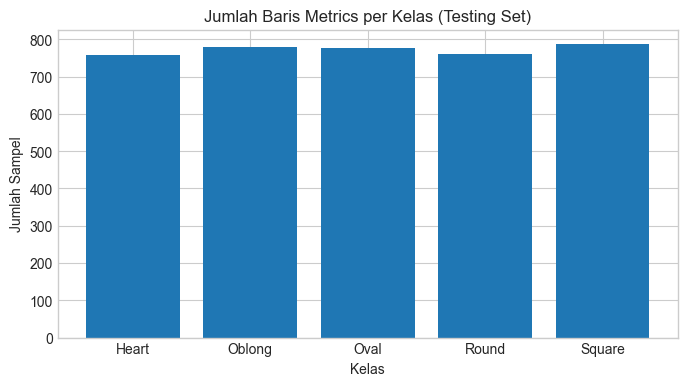

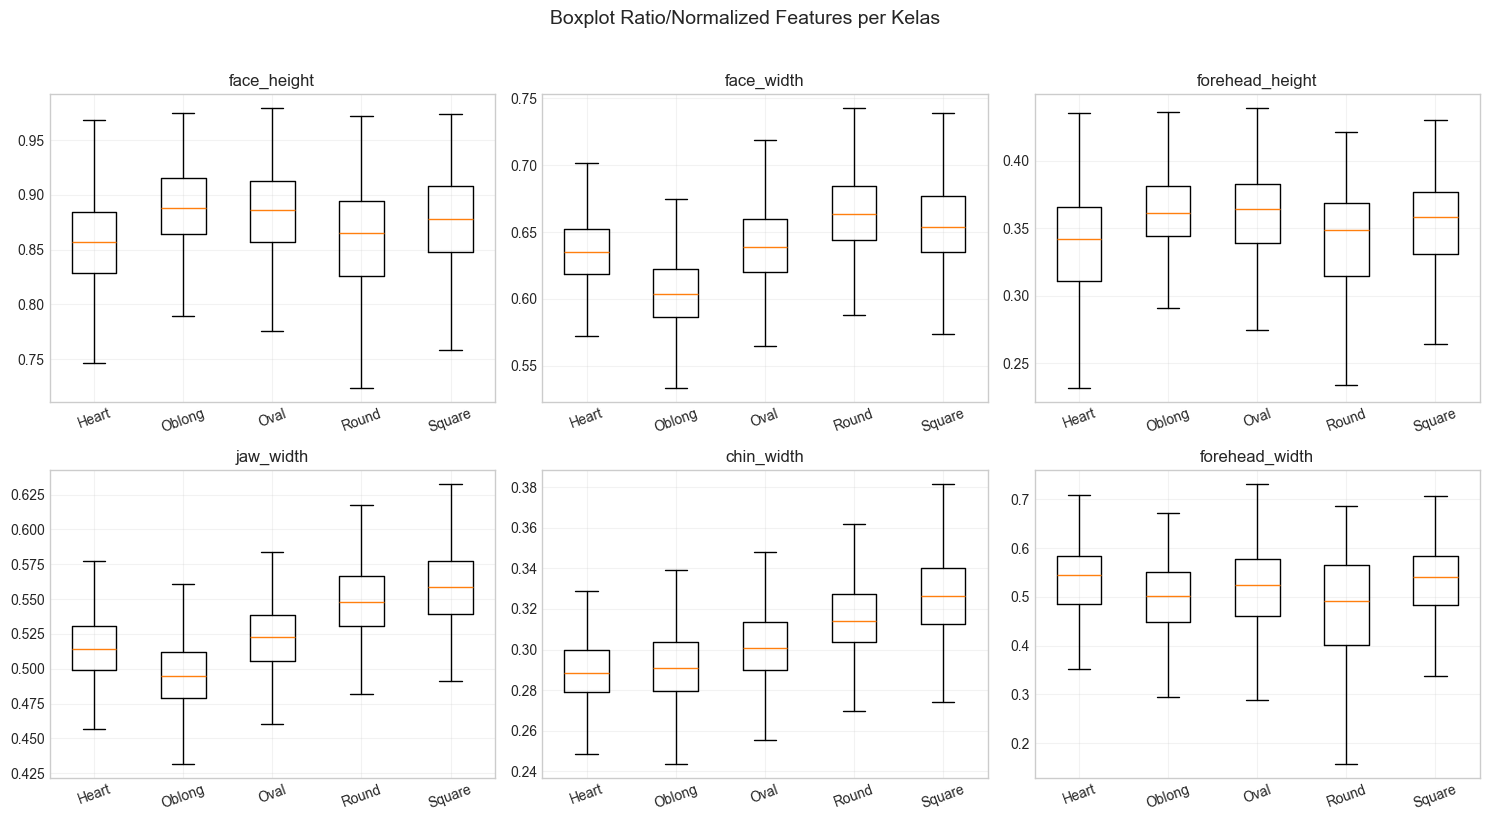

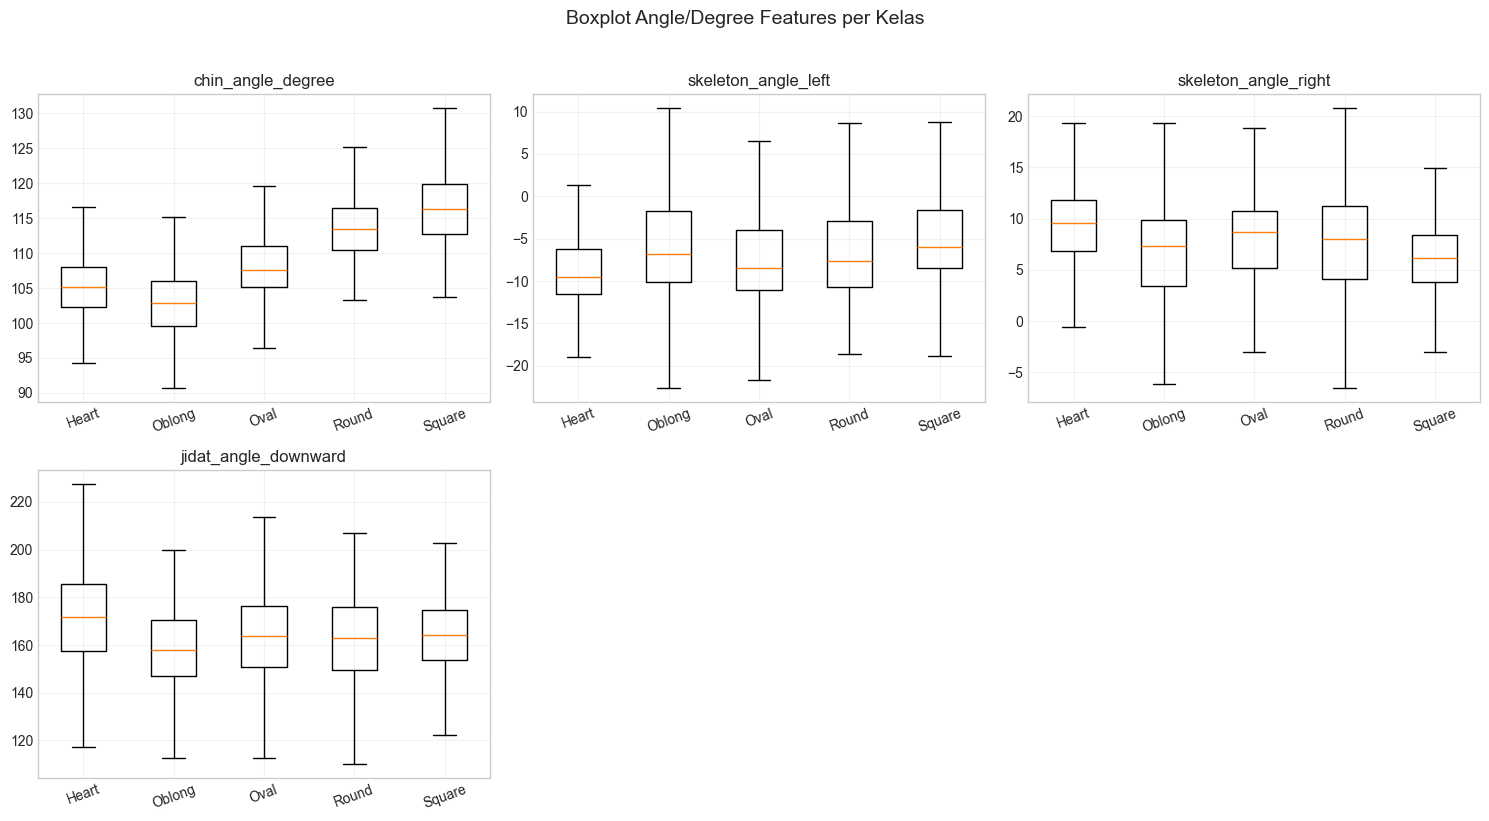

In [14]:
rows_per_class = metrics_df["class_name"].value_counts().sort_index()

plt.figure(figsize=(8, 4))
plt.bar(rows_per_class.index, rows_per_class.values)
plt.title("Jumlah Baris Metrics per Kelas (Testing Set)")
plt.ylabel("Jumlah Sampel")
plt.xlabel("Kelas")
plt.xticks(rotation=0)
plt.show()

def plot_box_grid(df, cols, title_prefix, class_order=None, ncols=3):
    if not cols:
        print(f"Tidak ada kolom untuk {title_prefix}")
        return

    if class_order is None:
        class_order = sorted(df["class_name"].dropna().unique().tolist())

    n = len(cols)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]
        data = [df.loc[df["class_name"] == c, col].dropna().values for c in class_order]
        ax.boxplot(data, tick_labels=class_order, showfliers=False)
        ax.set_title(col)
        ax.tick_params(axis="x", rotation=20)
        ax.grid(alpha=0.25)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    fig.suptitle(title_prefix, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

plot_box_grid(metrics_df, ratio_cols, "Boxplot Ratio/Normalized Features per Kelas")
plot_box_grid(metrics_df, angle_cols, "Boxplot Angle/Degree Features per Kelas")

## 5) Profil Kelas dengan Z-Score (Relative Features)


Menunjukkan posisi rata-rata setiap kelas terhadap mean global fitur ratio/normalized. Positif berarti di atas rata-rata global, negatif berarti di bawah.

,face_height,face_width,forehead_height,jaw_width,chin_width,forehead_width
class_name,,,,,,
Heart,-0.267,-0.113,-0.232,-0.382,-0.665,0.174
Oblong,0.310,-0.957,0.248,-0.914,-0.553,-0.050
Oval,0.186,0.003,0.205,-0.154,-0.158,0.012
Round,-0.306,0.661,-0.290,0.578,0.427,-0.311
Square,0.062,0.413,0.055,0.866,0.931,0.170


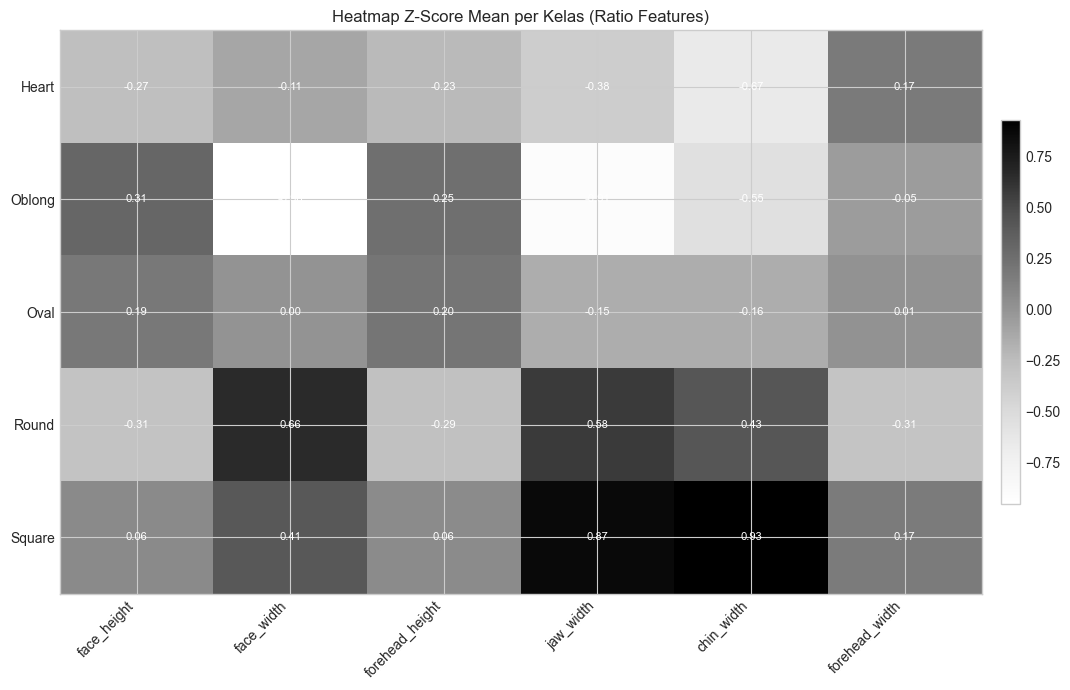

In [15]:
if ratio_cols:
    class_mean = metrics_df.groupby("class_name")[ratio_cols].mean()
    global_mean = metrics_df[ratio_cols].mean()
    global_std = metrics_df[ratio_cols].std(ddof=0).replace(0, np.nan)

    z_profile = (class_mean - global_mean) / global_std
    display(z_profile.round(3))

    z_vals = z_profile.fillna(0).values
    fig, ax = plt.subplots(figsize=(1.8 * len(ratio_cols), 1.0 * len(z_profile.index) + 2))
    im = ax.imshow(z_vals, aspect="auto")
    ax.set_xticks(np.arange(len(ratio_cols)))
    ax.set_xticklabels(ratio_cols, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(z_profile.index)))
    ax.set_yticklabels(z_profile.index)
    ax.set_title("Heatmap Z-Score Mean per Kelas (Ratio Features)")

    for r in range(z_vals.shape[0]):
        for c in range(z_vals.shape[1]):
            ax.text(c, r, f"{z_vals[r, c]:.2f}", ha="center", va="center", fontsize=8, color="white")

    plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
    plt.tight_layout()
    plt.show()
else:
    print("ratio_cols kosong, heatmap z-score tidak dibuat.")

## 6) Outlier Analysis Per Kelas (IQR + Z-Score)


Menghitung jumlah outlier per fitur untuk setiap kelas dan menampilkan sampel paling ekstrem berdasarkan absolute z-score global.

In [16]:
analysis_cols = ratio_cols + angle_cols

def iqr_outlier_count(series: pd.Series) -> int:
    s = series.dropna()
    if len(s) < 4:
        return 0
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    return int(((s < low) | (s > high)).sum())

if analysis_cols:
    outlier_rows = []
    for cls in sorted(metrics_df["class_name"].dropna().unique()):
        cls_df = metrics_df[metrics_df["class_name"] == cls]
        for col in analysis_cols:
            outlier_rows.append({
                "class_name": cls,
                "feature": col,
                "outlier_count": iqr_outlier_count(cls_df[col]),
                "sample_count": int(cls_df[col].notna().sum()),
            })
    outlier_table = pd.DataFrame(outlier_rows)
    outlier_table["outlier_pct"] = np.where(
        outlier_table["sample_count"] > 0,
        outlier_table["outlier_count"] / outlier_table["sample_count"] * 100,
        np.nan,
    )
    display(outlier_table.sort_values(["outlier_pct", "outlier_count"], ascending=False).head(25).round(2))

    extreme_rows = []
    for col in analysis_cols:
        s = metrics_df[col]
        std = float(s.std(ddof=0))
        if np.isnan(std) or std < 1e-12:
            continue
        z = ((s - float(s.mean())) / std).abs()
        top_idx = z.nlargest(min(10, len(z))).index
        tmp = metrics_df.loc[top_idx, ["class_name", "image_file", "relative_path", col]].copy()
        tmp["feature"] = col
        tmp["abs_z"] = z.loc[top_idx].values
        extreme_rows.append(tmp)

    if extreme_rows:
        extreme_df = (
            pd.concat(extreme_rows, ignore_index=True)
            .sort_values("abs_z", ascending=False)
            .drop_duplicates(subset=["feature", "relative_path"])
        )
        display(extreme_df.head(30).round(4))
else:
    print("analysis_cols kosong, outlier analysis dilewati.")

,class_name,feature,outlier_count,sample_count,outlier_pct
7,Heart,skeleton_angle_left,73,758,9.63
39,Round,jidat_angle_downward,65,761,8.54
8,Heart,skeleton_angle_right,64,758,8.44
25,Oval,forehead_width,58,778,7.46
35,Round,forehead_width,53,761,6.96
5,Heart,forehead_width,51,758,6.73
49,Square,jidat_angle_downward,52,787,6.61
45,Square,forehead_width,51,787,6.48
28,Oval,skeleton_angle_right,50,778,6.43
48,Square,skeleton_angle_right,47,787,5.97


,class_name,image_file,relative_path,face_height,feature,abs_z,face_width,forehead_height,jaw_width,chin_width,forehead_width,chin_angle_degree,skeleton_angle_left,skeleton_angle_right,jidat_angle_downward
20,Round,round (657).jpg,Round/round (657).jpg,NaN,forehead_height,6.7288,NaN,0.0441,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,Round,round (657).jpg,Round/round (657).jpg,0.5307,face_height,6.5638,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21,Round,round (594).jpg,Round/round (594).jpg,NaN,forehead_height,6.5223,NaN,0.0534,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22,Round,round (280).jpg,Round/round (280).jpg,NaN,forehead_height,6.2166,NaN,0.0672,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Round,round (594).jpg,Round/round (594).jpg,0.5496,face_height,6.1988,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,Round,round (591).jpg,Round/round (591).jpg,NaN,forehead_height,6.1457,NaN,0.0704,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,Square,square (909).jpg,Square/square (909).jpg,NaN,forehead_height,6.1120,NaN,0.0719,NaN,NaN,NaN,NaN,NaN,NaN,NaN
90,Round,round (591).jpg,Round/round (591).jpg,NaN,jidat_angle_downward,6.0627,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,323.4034
91,Heart,heart (130).jpg,Heart/heart (130).jpg,NaN,jidat_angle_downward,5.9162,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,319.5739
92,Round,round (652).jpg,Round/round (652).jpg,NaN,jidat_angle_downward,5.8840,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,318.7314


## 7) Visual Check: Gallery `face_masked` & `face_skin` Per Kelas


Visualisasi ini membantu memastikan bahwa metrics yang dinormalisasi terhadap max dimension tetap konsisten dengan kualitas hasil masking/skin extraction.

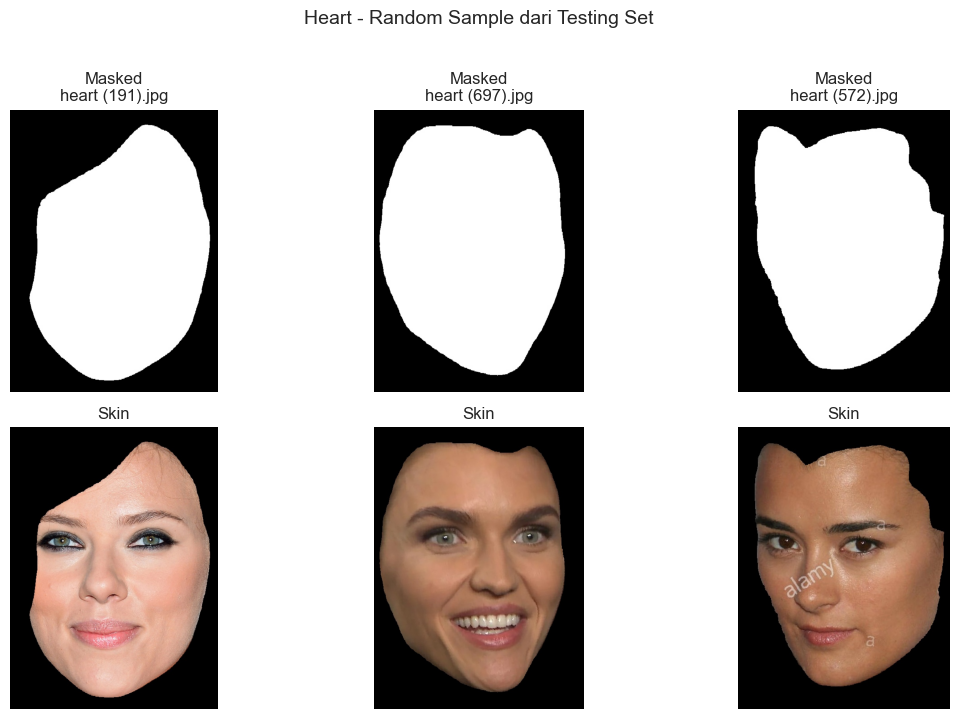

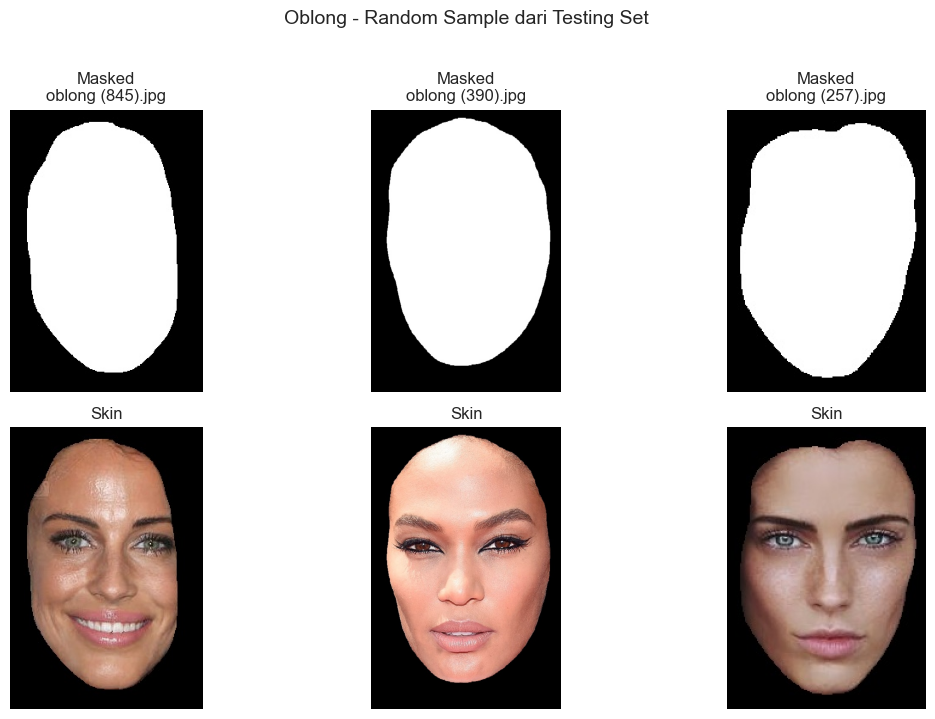

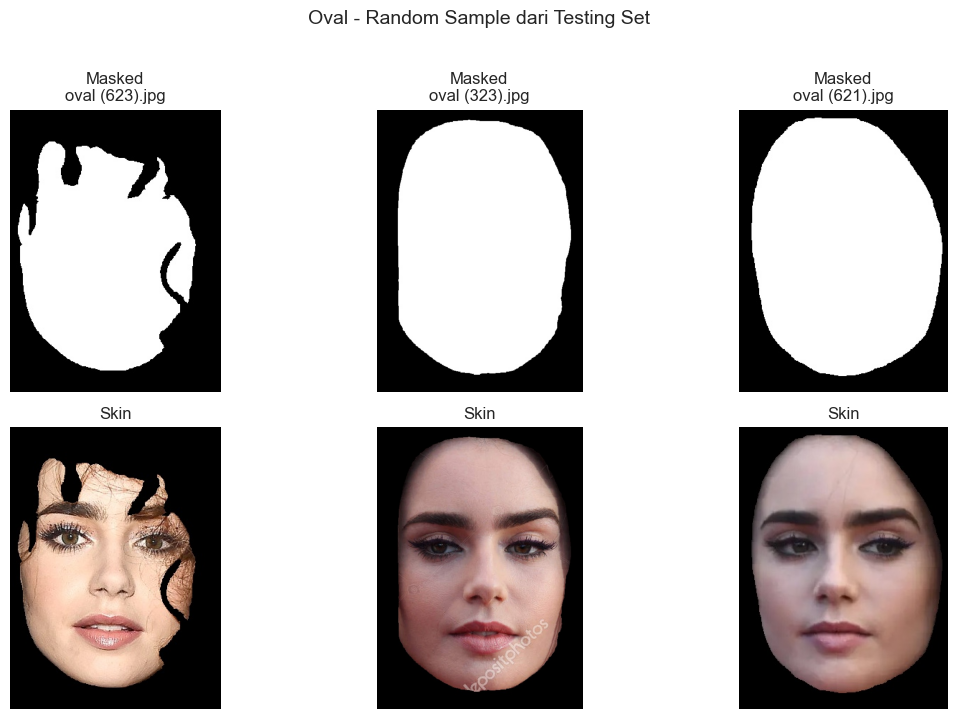

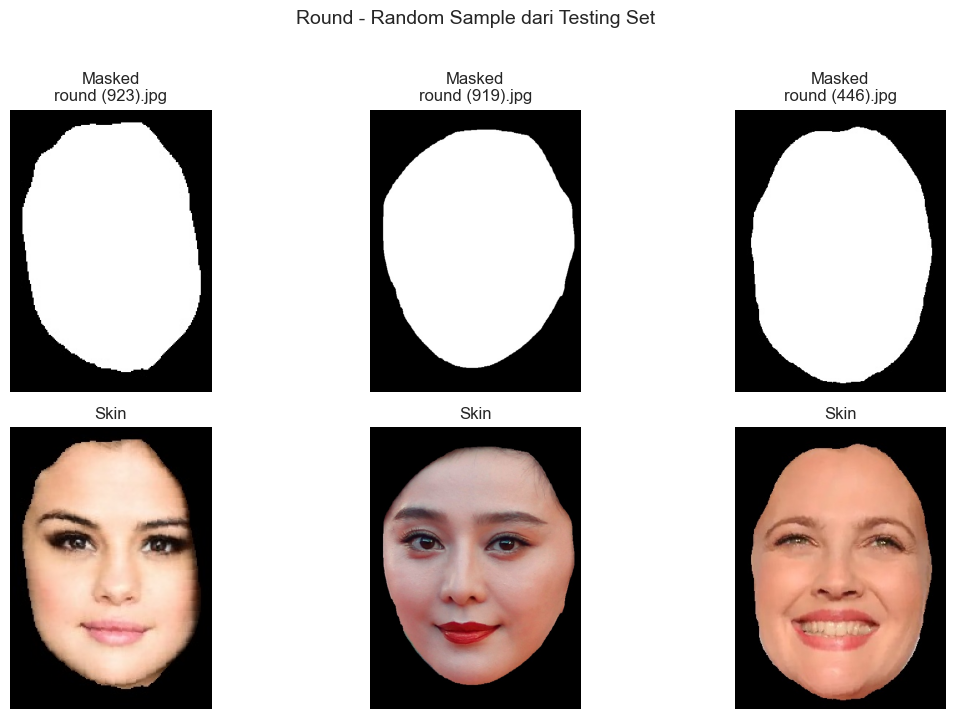

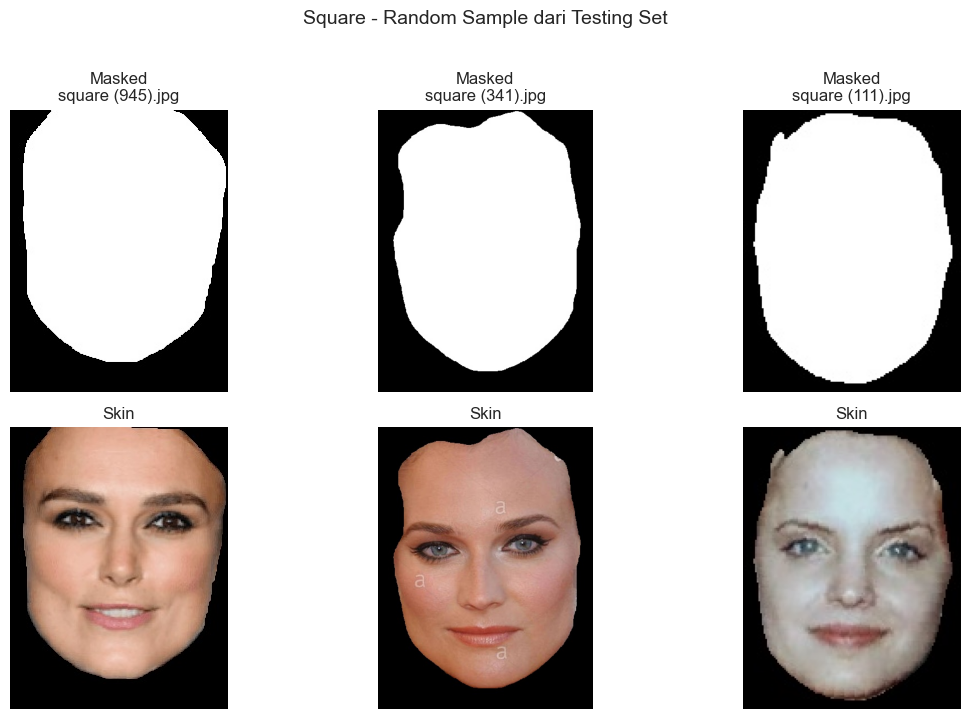

In [17]:
def read_rgb(img_path: str):
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def show_class_gallery(df, cls, n_samples=3, random_state=42):
    cls_df = df[
        (df["class_name"] == cls)
        & (df["face_masked_exists"] == True)
        & (df["face_skin_exists"] == True)
    ].copy()

    if cls_df.empty:
        print(f"[SKIP] {cls}: tidak ada pasangan face_masked + face_skin yang valid")
        return

    n = min(n_samples, len(cls_df))
    sample_df = cls_df.sample(n=n, random_state=random_state).reset_index(drop=True)

    fig, axes = plt.subplots(2, n, figsize=(4 * n, 7), squeeze=False)
    fig.suptitle(f"{cls} - Random Sample dari Testing Set", fontsize=14, y=1.02)

    for i, row in sample_df.iterrows():
        masked = read_rgb(row["face_masked_path"])
        skin = read_rgb(row["face_skin_path"])

        axes[0, i].imshow(masked if masked is not None else np.zeros((32, 32, 3), dtype=np.uint8))
        axes[0, i].set_title(f"Masked\n{row['image_file']}")
        axes[0, i].axis("off")

        axes[1, i].imshow(skin if skin is not None else np.zeros((32, 32, 3), dtype=np.uint8))
        axes[1, i].set_title("Skin")
        axes[1, i].axis("off")

    plt.tight_layout()
    plt.show()

for cls in sorted(metrics_df["class_name"].dropna().unique()):
    show_class_gallery(metrics_df, cls, n_samples=3, random_state=42)

## 8) Visual Check Berbasis Nilai Ekstrem Metrics


Untuk metrik fokus, tampilkan sampel bernilai minimum dan maksimum pada setiap kelas (dengan pasangan `face_masked` dan `face_skin`) agar lebih mudah evaluasi rule threshold.

Focus metric: face_height


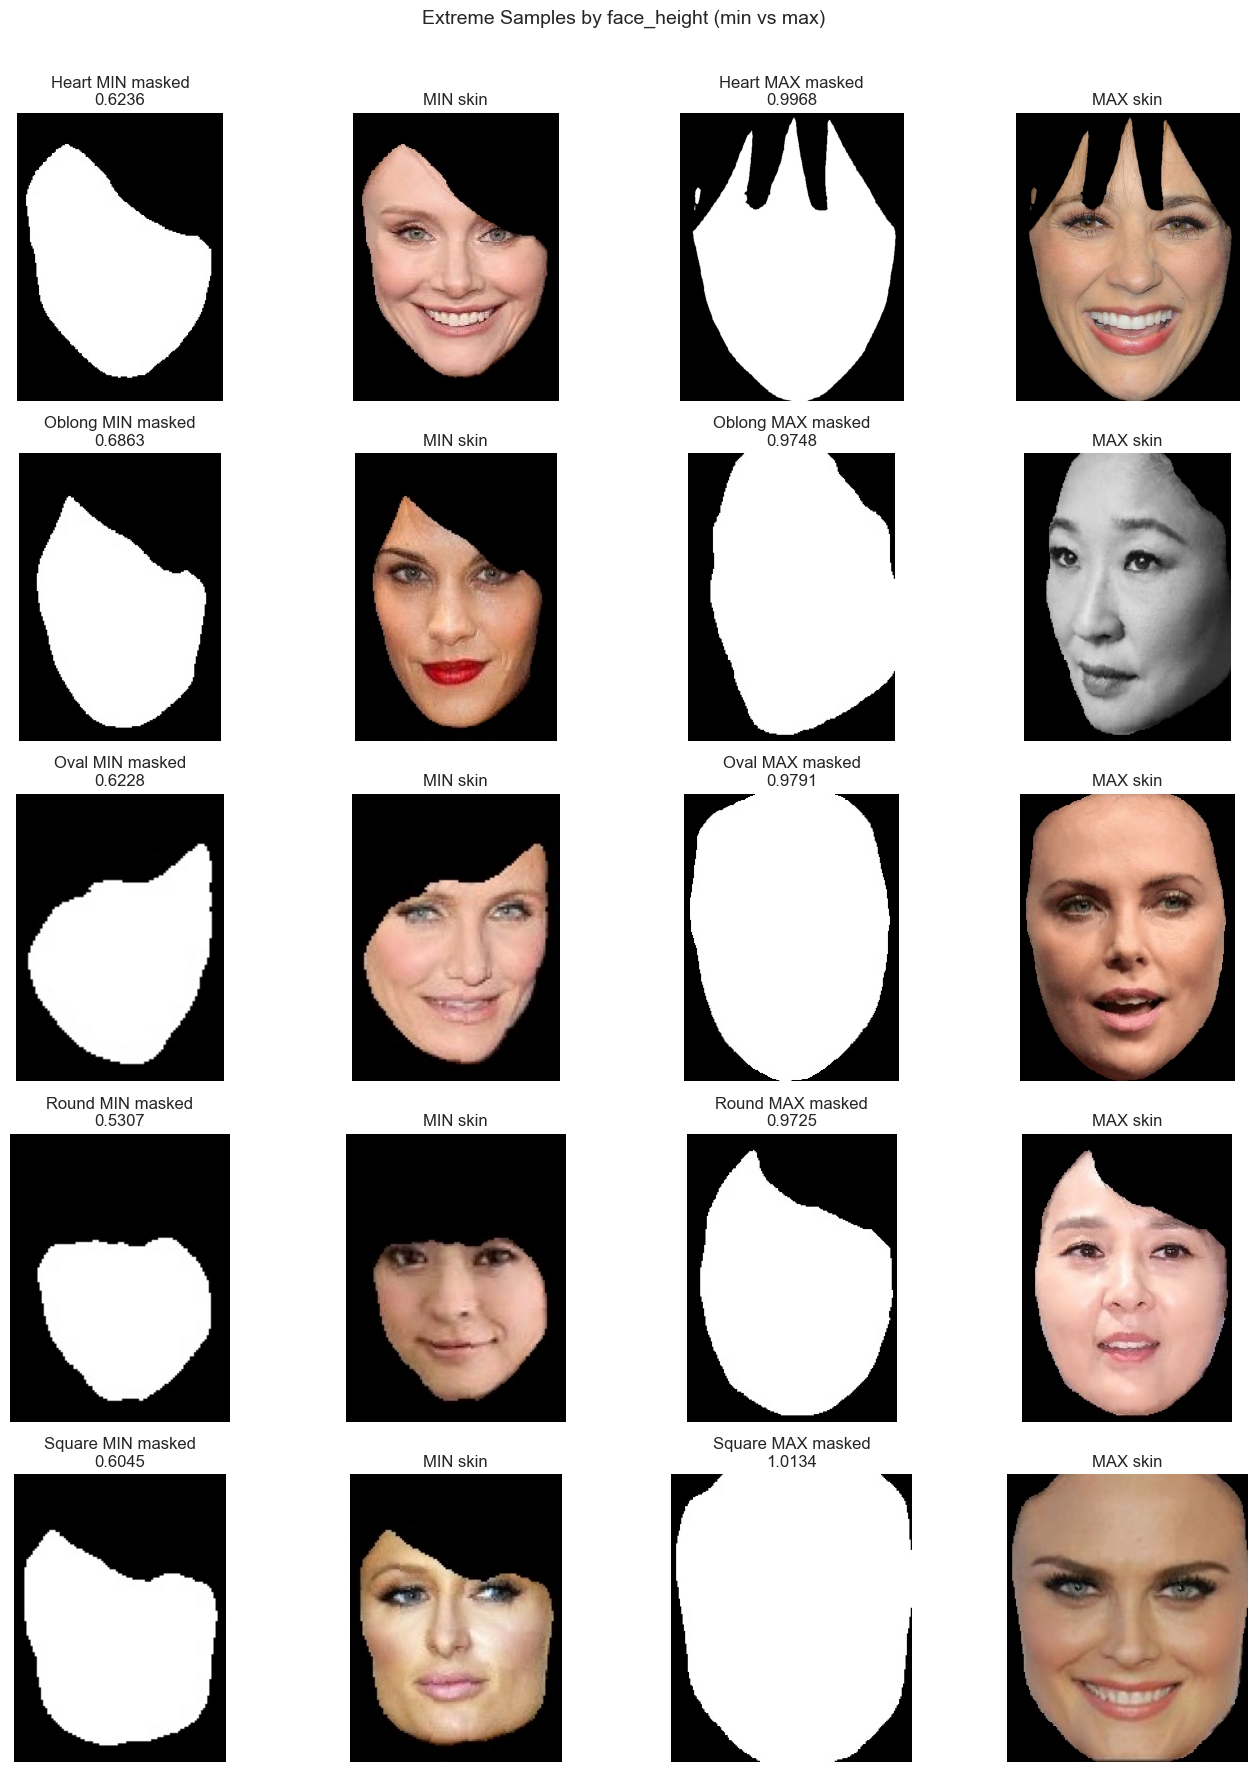

In [18]:
focus_metric_candidates = [
    "face_height",
    "face_width",
    "forehead_height",
    "jaw_width",
    "chin_width",
    "forehead_width",
    "chin_angle_degree",
    "jidat_angle_downward",
]

focus_metric = next((c for c in focus_metric_candidates if c in metrics_df.columns), None)
print("Focus metric:", focus_metric)

def show_extreme_per_class(df, metric_col):
    if metric_col is None or metric_col not in df.columns:
        print("Kolom metric tidak ditemukan.")
        return

    classes = sorted(df["class_name"].dropna().unique())
    fig, axes = plt.subplots(len(classes), 4, figsize=(14, 3.5 * len(classes)), squeeze=False)
    fig.suptitle(f"Extreme Samples by {metric_col} (min vs max)", fontsize=14, y=1.01)

    for r, cls in enumerate(classes):
        cls_df = df[
            (df["class_name"] == cls)
            & (df["face_masked_exists"] == True)
            & (df["face_skin_exists"] == True)
            & (df[metric_col].notna())
        ].copy()

        if cls_df.empty:
            for c in range(4):
                axes[r, c].text(0.5, 0.5, f"{cls}: data kosong", ha="center", va="center")
                axes[r, c].axis("off")
            continue

        row_min = cls_df.loc[cls_df[metric_col].idxmin()]
        row_max = cls_df.loc[cls_df[metric_col].idxmax()]

        min_masked = read_rgb(row_min["face_masked_path"])
        min_skin = read_rgb(row_min["face_skin_path"])
        max_masked = read_rgb(row_max["face_masked_path"])
        max_skin = read_rgb(row_max["face_skin_path"])

        axes[r, 0].imshow(min_masked if min_masked is not None else np.zeros((32, 32, 3), dtype=np.uint8))
        axes[r, 0].set_title(f"{cls} MIN masked\n{row_min[metric_col]:.4f}")
        axes[r, 0].axis("off")

        axes[r, 1].imshow(min_skin if min_skin is not None else np.zeros((32, 32, 3), dtype=np.uint8))
        axes[r, 1].set_title("MIN skin")
        axes[r, 1].axis("off")

        axes[r, 2].imshow(max_masked if max_masked is not None else np.zeros((32, 32, 3), dtype=np.uint8))
        axes[r, 2].set_title(f"{cls} MAX masked\n{row_max[metric_col]:.4f}")
        axes[r, 2].axis("off")

        axes[r, 3].imshow(max_skin if max_skin is not None else np.zeros((32, 32, 3), dtype=np.uint8))
        axes[r, 3].set_title("MAX skin")
        axes[r, 3].axis("off")

    plt.tight_layout()
    plt.show()

show_extreme_per_class(metrics_df, focus_metric)

## 9) Kandidat Rule-Based Range Per Kelas (Q1, Median, Q3)


Range kuartil per kelas bisa dipakai sebagai baseline awal untuk menyusun rule threshold fitur bentuk wajah.

In [19]:
rule_cols = ratio_cols + angle_cols
if not rule_cols:
    raise ValueError("Tidak ada kolom ratio/angle untuk rule-based summary")

quartile_summary = (
    metrics_df.groupby("class_name")[rule_cols]
    .quantile([0.25, 0.50, 0.75])
    .rename(index={0.25: "q1", 0.5: "median", 0.75: "q3"}, level=1)
    .reset_index()
    .sort_values(["class_name", "level_1"])
)
quartile_summary = quartile_summary.rename(columns={"level_1": "quantile"})
display(quartile_summary.round(4))

analysis_out_dir = OUTPUT_TRAINING_DIR / "_analysis"
analysis_out_dir.mkdir(parents=True, exist_ok=True)

quality_per_class.to_csv(analysis_out_dir / "training_set_quality_per_class.csv", index=False)
if not ratio_summary.empty:
    ratio_summary.to_csv(analysis_out_dir / "training_set_ratio_summary.csv", index=False)
if not angle_summary.empty:
    angle_summary.to_csv(analysis_out_dir / "training_set_angle_summary.csv", index=False)
quartile_summary.to_csv(analysis_out_dir / "training_set_quartile_summary.csv", index=False)

print(f"File summary tersimpan di: {analysis_out_dir}")

,class_name,quantile,face_height,face_width,forehead_height,jaw_width,chin_width,forehead_width,chin_angle_degree,skeleton_angle_left,skeleton_angle_right,jidat_angle_downward
1,Heart,median,0.8566,0.6353,0.3417,0.5141,0.2887,0.5458,105.2162,-9.4623,9.5650,171.7140
0,Heart,q1,0.8289,0.6188,0.3106,0.4990,0.2791,0.4859,102.2421,-11.4660,6.8428,157.5014
2,Heart,q3,0.8849,0.6522,0.3658,0.5305,0.2997,0.5838,108.0754,-6.2635,11.8396,185.7099
4,Oblong,median,0.8885,0.6037,0.3612,0.4945,0.2907,0.5024,102.8504,-6.8428,7.3190,157.7990
3,Oblong,q1,0.8645,0.5862,0.3445,0.4792,0.2798,0.4483,99.5960,-10.0891,3.4405,147.0723
5,Oblong,q3,0.9154,0.6224,0.3813,0.5122,0.3039,0.5519,105.9498,-1.7086,9.8750,170.5802
7,Oval,median,0.8859,0.6389,0.3645,0.5229,0.3006,0.5246,107.6315,-8.4152,8.6583,163.6703
6,Oval,q1,0.8573,0.6198,0.3393,0.5054,0.2900,0.4611,105.1512,-11.0388,5.1617,150.7604
8,Oval,q3,0.9125,0.6595,0.3825,0.5388,0.3135,0.5776,111.0137,-3.9458,10.7193,176.3320
10,Round,median,0.8654,0.6638,0.3489,0.5478,0.3141,0.4925,113.4542,-7.6668,8.0047,163.0684


File summary tersimpan di: D:\Thoriq\Work\MadeByHumans\Research Face Shape\output\training_set\_analysis
